Employment in the US retail sector
We will look at several methods for obtaining the components and later in this chapter, but first it is helpful to see an example. We will decompose the monthly total number of persons in thousands employed in the retail sector across the US since 1990

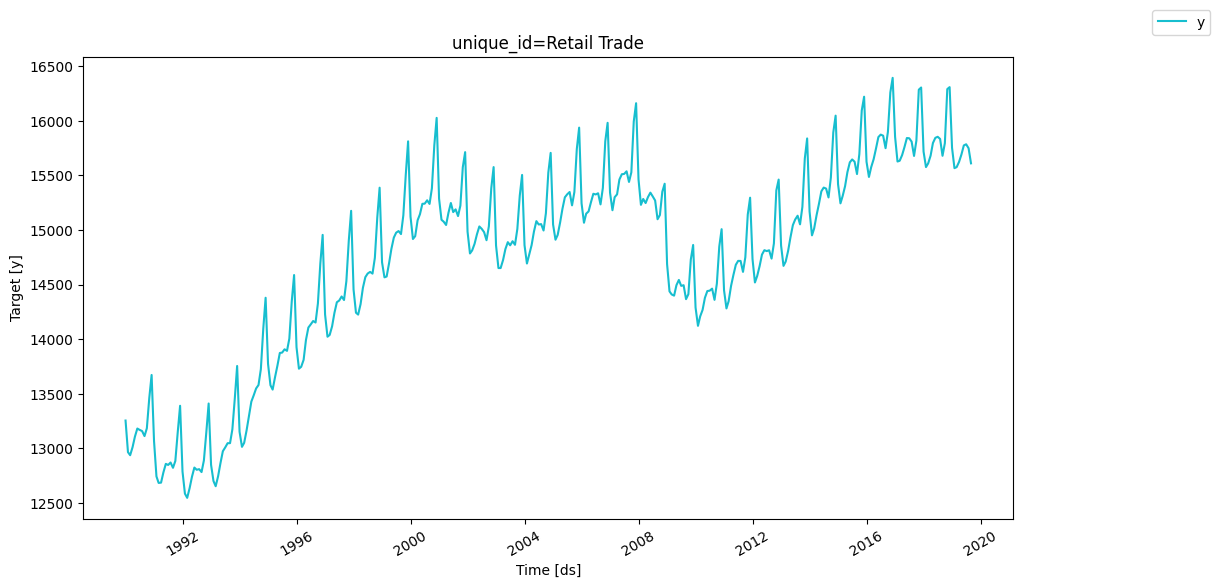

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
fig,ax=plt.subplots(figsize=(12,6))
us_employement=pd.read_csv("data/us_employment.csv",parse_dates=['ds'])
us_retail_employement=(us_employement.loc[lambda x:(x["unique_id"]=="Retail Trade") & (x["ds"]>="1990")])
plot_series(us_retail_employement,ax=ax)

In [2]:
from statsmodels.tsa.seasonal import STL,seasonal_decompose
import calendar
from coreforecast.scalers import boxcox,boxcox_lambda
stl=STL(us_retail_employement['y'],period=12)
res=stl.fit()
dcmp=pd.DataFrame({
    "ds":us_retail_employement['ds'],
    "data":us_retail_employement['y'],
    "trend":res.trend,
    "seasonal":res.seasonal,
    "reminder":res.resid,  
}).reset_index(drop=True)


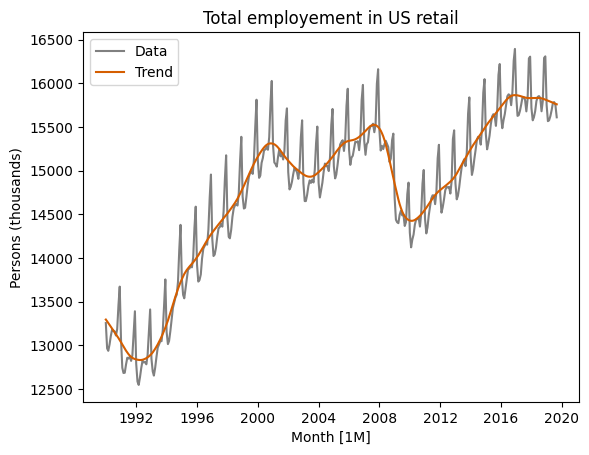

In [3]:
import seaborn as sns
fig,ax=plt.subplots()
sns.lineplot(data=dcmp,x="ds",y="data",color="gray",label="Data")
sns.lineplot(data=dcmp,x="ds",y="trend",color="#D55E00",label="Trend")
ax.set(
    title="Total employement in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

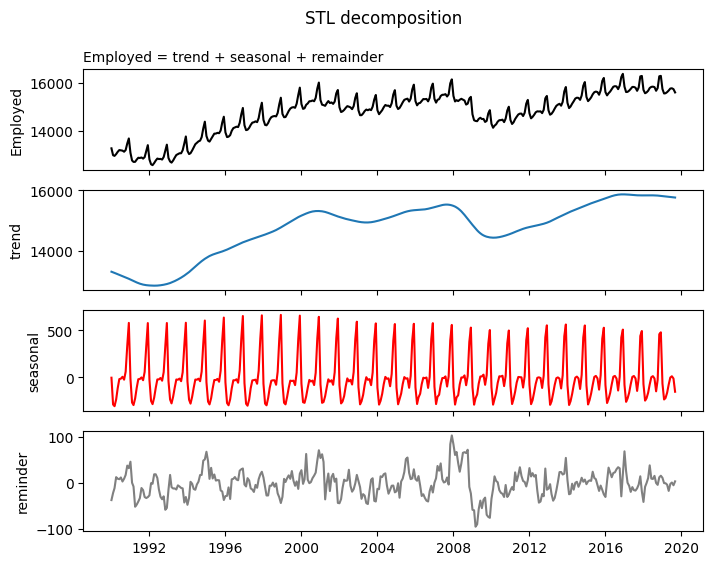

In [4]:
fig,axes=plt.subplots(4,1,sharex=True,figsize=(8,6))
sns.lineplot(data=dcmp,x="ds",y="data",ax=axes[0],color="black")
sns.lineplot(data=dcmp,x="ds",y="seasonal",ax=axes[2],color="red")
sns.lineplot(data=dcmp,x="ds",y="reminder",ax=axes[3],color="grey")
sns.lineplot(data=dcmp,x="ds",y="trend",ax=axes[1])
axes[0].set_title("Employed = trend + seasonal + remainder",size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()


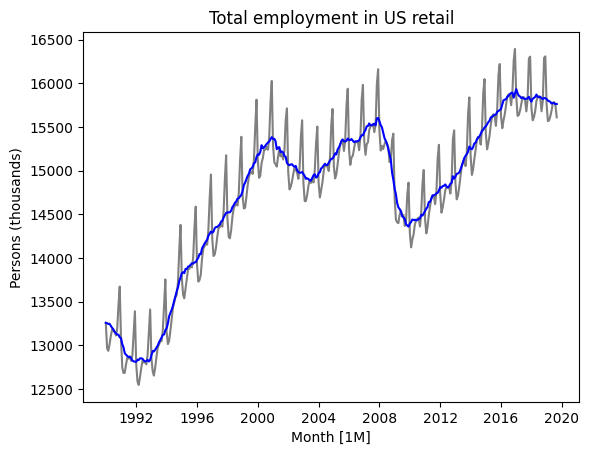

In [7]:
# the data without the Seasonality factor will look like this
df=dcmp.assign(adj=lambda x:x["data"]-x["seasonal"])
fig,ax=plt.subplots()
sns.lineplot(data=df,x="ds",y="data",color="grey")
sns.lineplot(data=df,x="ds",y="adj",color="blue")
ax.set( title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",)
plt.show()


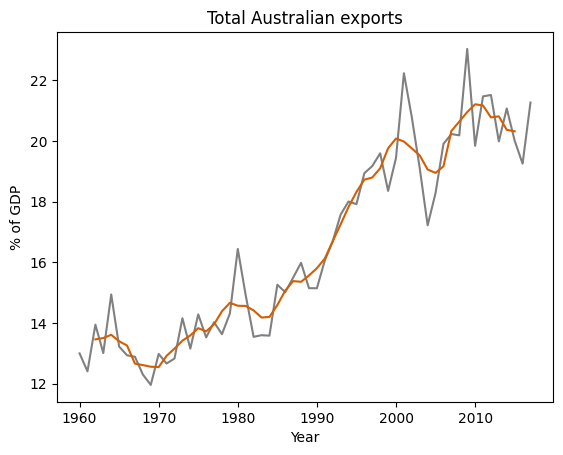

In [8]:
global_econ=pd.read_csv("data/global_economy.csv")
global_aus_econ=global_econ.loc[lambda x:x["unique_id"]=="Australia"]
df=global_econ.loc[lambda x:x["unique_id"]=="Australia"].assign(MA_5=lambda x:x["Exports"].rolling(5,center=True).mean())
fig,ax=plt.subplots()
sns.lineplot(data=global_aus_econ,x="ds",y="Exports",color="grey")
sns.lineplot(data=df,x="ds",y="MA_5",color="#D55E00")
ax.set(
    title="Total Australian exports",
    xlabel="Year",
    ylabel="% of GDP",
)
plt.show()





1. Consider the GDP information in global_economy. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

df=pd.read_csv("data/global_economy.csv",parse_dates=['ds'])
df.head()
 

,unique_id,Code,ds,GDP,Growth,CPI,Imports,Exports,Population
0,Afghanistan,AFG,1960-01-01,5.377778e+08,NaN,NaN,7.024793,4.132233,8996351.0
1,Afghanistan,AFG,1961-01-01,5.488889e+08,NaN,NaN,8.097166,4.453443,9166764.0
2,Afghanistan,AFG,1962-01-01,5.466667e+08,NaN,NaN,9.349593,4.878051,9345868.0
3,Afghanistan,AFG,1963-01-01,7.511112e+08,NaN,NaN,16.863910,9.171601,9533954.0
4,Afghanistan,AFG,1964-01-01,8.000000e+08,NaN,NaN,18.055555,8.888893,9731361.0


In [20]:
df['CPI']=df['GDP']/df['Population']
df['unique_id'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Arab World', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas, The', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Caribbean small states', 'Cayman Islands',
       'Central African Republic', 'Central Europe and the Baltics',
       'Chad', 'Channel Islands', 'Chile', 'China', 'Colombia', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic',
       'Early-demographic dividend', 'East Asia & Pacif

In [3]:
df_highest=df.groupby(['unique_id'])['CPI'].max().sort_values(ascending=False)
df_highest.head()

unique_id
Monaco              185152.527227
Liechtenstein       179308.075616
Luxembourg          119225.380023
Norway              103059.248228
Macao SAR, China     94004.389829
Name: CPI, dtype: float64

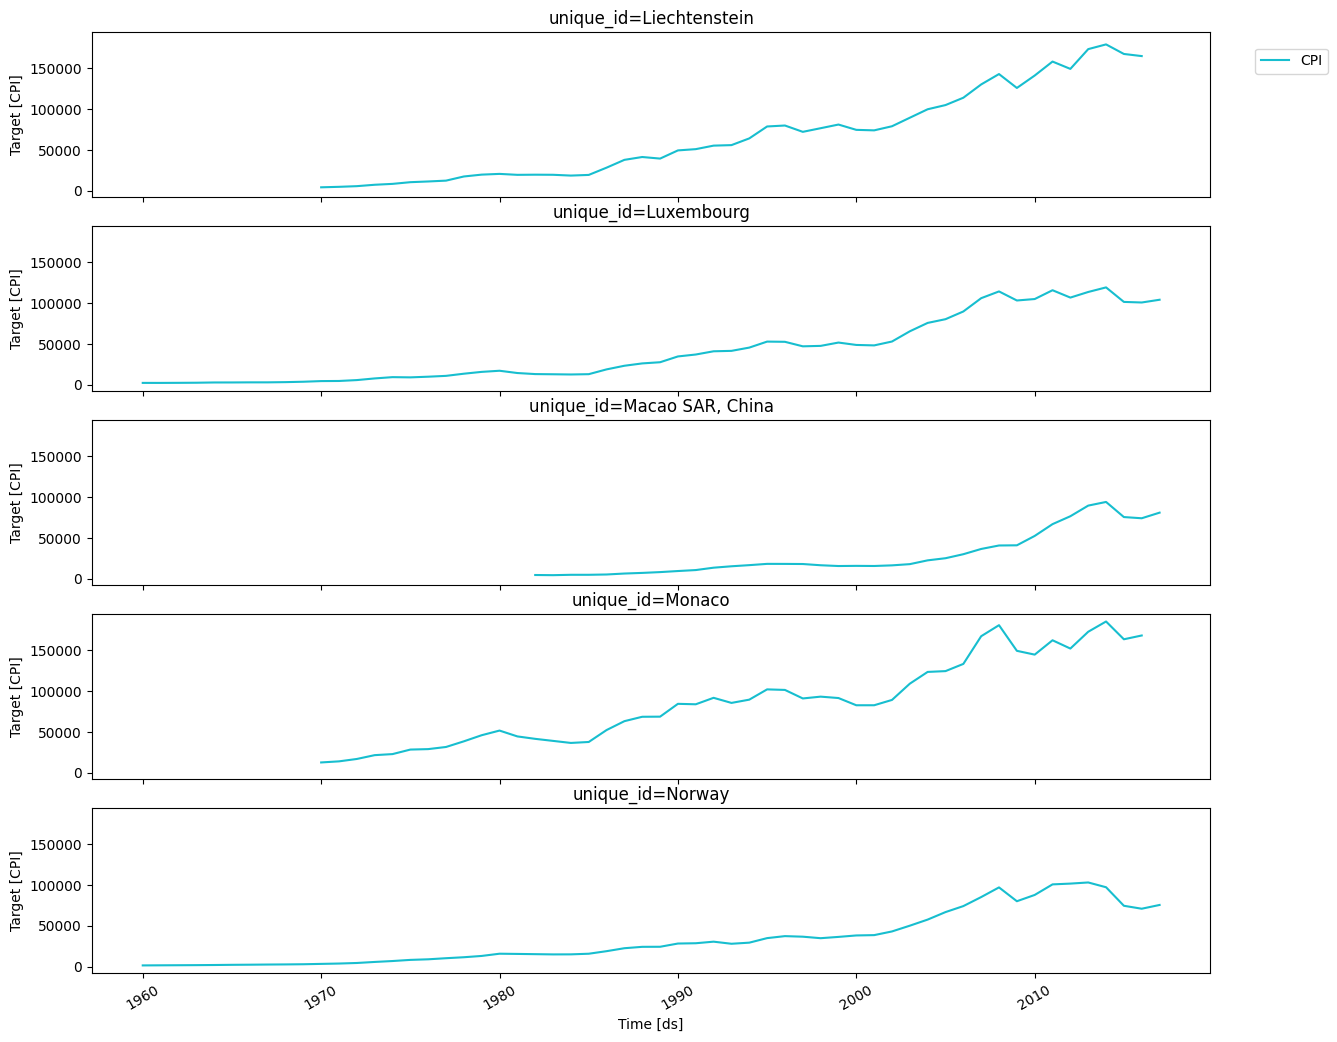

In [19]:
target=['Monaco','Liechtenstein','Luxembourg','Norway','Macao SAR, China']
top_5_CPI=df.loc[lambda x:x['unique_id'].isin(target)]
fig,ax=plt.subplots(nrows=5,figsize=(12,10),sharey=True,sharex=True)
plt.tight_layout()
plot_series(top_5_CPI,target_col="CPI",ax=ax)



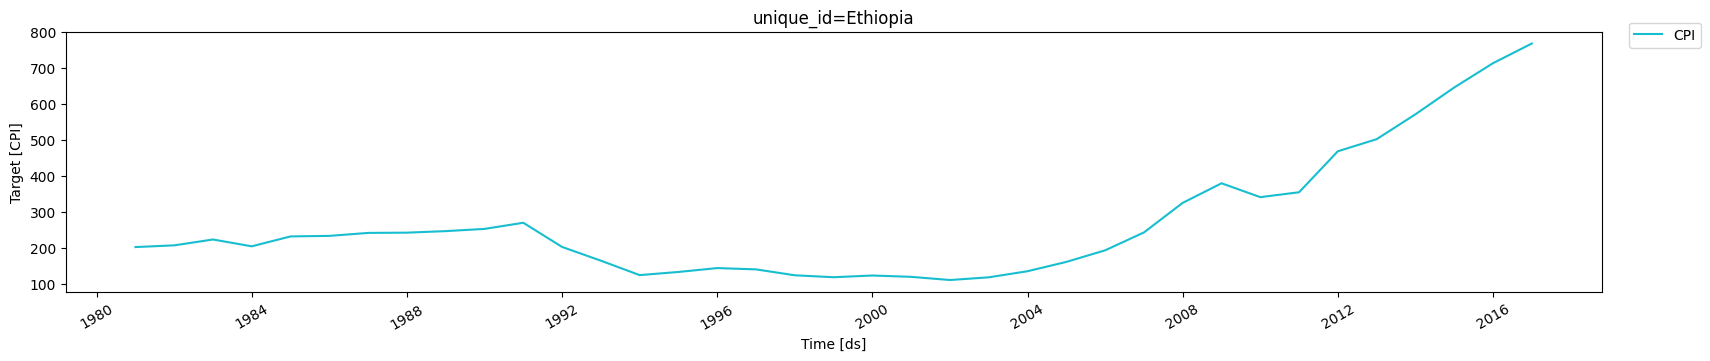

In [21]:
ethio_CPI=df[df['unique_id']=='Ethiopia']
plot_series(ethio_CPI,target_col='CPI')